In [3]:
# Ensure we are using the latest on-disk version of the Set module
import importlib
import RTD_Calibration_VGP.src.set as set_mod
print('Reloading module from:', getattr(set_mod, '__file__', 'unknown'))
importlib.reload(set_mod)
from RTD_Calibration_VGP.src.set import Set
print('Module reloaded and Set imported')


Reloading module from: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py
Module reloaded and Set imported


In [2]:
# Add repo root to sys.path so the package can be imported in-kernel
import sys
from pathlib import Path
# repo_root should point to the repository root (parent of RTD_Calibration_VGP)
repo_root = Path('..').resolve().parent if (Path('..').resolve().name == 'RTD_Calibration_VGP') else Path('..').resolve()
# ensure the repository root is the parent that contains RTD_Calibration_VGP
if (repo_root / 'RTD_Calibration_VGP').exists():
    sys.path.insert(0, str(repo_root))
    print('Inserted repo root into sys.path:', repo_root)
else:
    # fallback: insert the immediate parent and warn
    sys.path.insert(0, str(Path('..').resolve()))
    print('Warning: expected repo layout not found; inserted', Path('..').resolve(), 'into sys.path')

# Import local modules via package namespace
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.run import Run
from RTD_Calibration_VGP.src.set import Set
import pandas as pd

# Read the logfile from repo data folder (guard if missing)
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve() if (repo_root / 'RTD_Calibration_VGP').exists() else (repo_root / 'data' / 'LogFile.csv').resolve()
if not logfile_path.exists():
    print(f'Warning: logfile not found at {logfile_path}. Create or provide RTD_Calibration_VGP/data/LogFile.csv before running data processing cells.')
    logfile_df = pd.DataFrame()
else:
    logfiles = Logfile(filepath=str(logfile_path))
    logfile_df = logfiles.log_file

# Select sets to process
selected_sets = [2, 4, 5, 7, 8, 9, 11, 12, 13, 15, 17, 18, 21, 22, 25, 26, 28, 29, 31, 32, 37, 38, 41, 42, 44, 47, 49, 51, 55, 60]  # adjust this list as needed

# Try to use the external YAML config if available
config_path = (repo_root / 'RTD_Calibration_VGP' / 'config' / 'config.yaml').resolve()
if config_path.exists():
    print(f'Using sensors config: {config_path}')
    set_instance = Set(logfile=logfile_df, config_path=str(config_path))
else:
    set_instance = Set(logfile=logfile_df)

# If logfile_df is empty the following calls will be no-ops or produce warnings
set_instance.group_runs_by_set(selected_sets=selected_sets)
set_instance.calculate_offsets_and_rms(selected_sets=selected_sets)
# Use outputs/ directory for generated plots
set_instance.offset_repeatability(selected_sets=selected_sets, ref=2, save_dir='outputs/plot_global_means')

# Weighted mean offsets and errors
calibration_constants, calibration_errors = set_instance.calculate_weighted_mean_offsets(selected_sets=selected_sets)

print('Set processing complete. You can now run the plotting cells to generate figures.')


Inserted repo root into sys.path: /Users/vicky/Desktop/rtd-calibration-ana
CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.

Processing CalibSetNumber: 2.0
    Excluded: 05042022_ln2_r48176_r48177_48190-48201_1_pre (contains 'pre' or 'st')
Temperature file found: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_2/05042022_ln2_r48176_r48177_48190-48201_1.txt
Columns with excessive NaNs: ['channel_8']
Temperature file processed successfully: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_2/05042022_ln2_r48176_r48177_48190-48201_1.txt
Associated sensors: {'channel_1': '48190', 'channel_2': '48191', 'channel_3': '48192', 'channel_4': '48193', 'channel_5': '48194', 'channel_6': '48195', 'channel_7': '48196', 'channel_8': '48197', 'channel_9': '48198', 'channel_10': '48199', 'channel_11': '48200', 'channel_12': '48201'

Processing 30 sets.
Set 2: len sensor_names=10, len global_means=10
  First sensor_name: '48190' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(830.6866205434924) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 4: len sensor_names=9, len global_means=9
  First sensor_name: '48480' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-13.924798414992452) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 5: len sensor_names=10, len global_means=10
  First sensor_name: '48492' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-33.899152223248684) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 7: len sensor_names=8, len global_means=8
  First sensor_name: '48748' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-34.159719516430805) (type: <class 'numpy.float64'>)
  All g

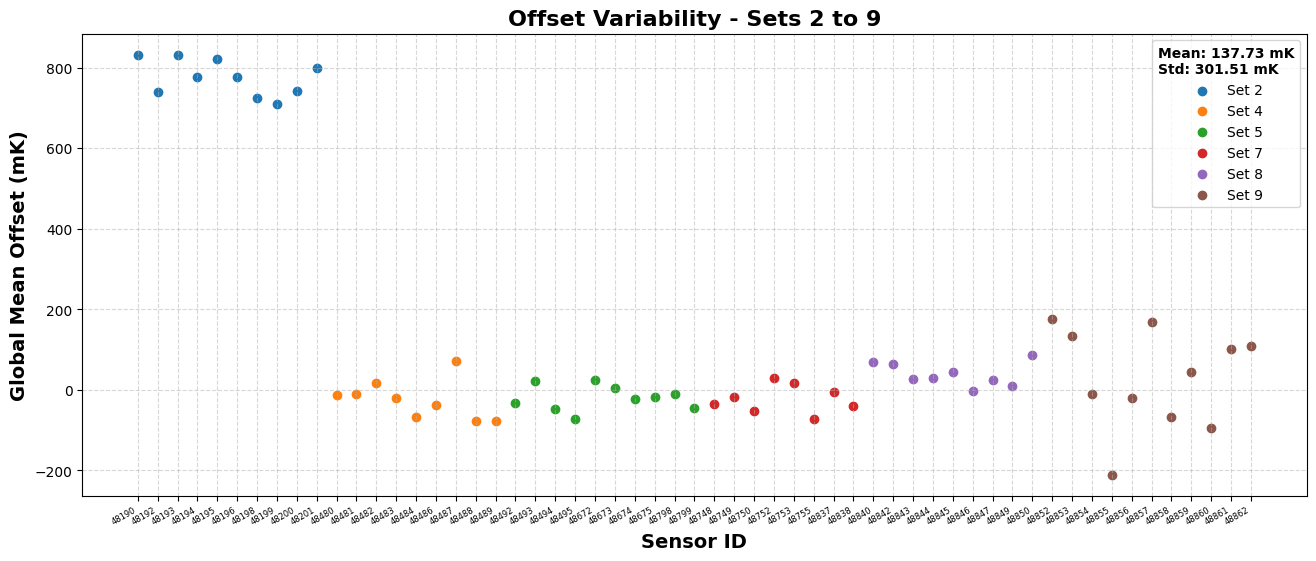

Set 11: len sensor_names=11, len global_means=11
  First sensor_name: '48876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(474.5711616109265) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 12: len sensor_names=11, len global_means=11
  First sensor_name: '48888' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-41.90747332782698) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 13: len sensor_names=11, len global_means=11
  First sensor_name: '48900' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-492.16611675545056) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 15: len sensor_names=9, len global_means=9
  First sensor_name: '48516' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(518.9729542055697) (type: <class 'numpy.float64'>)
  All global_mean types:

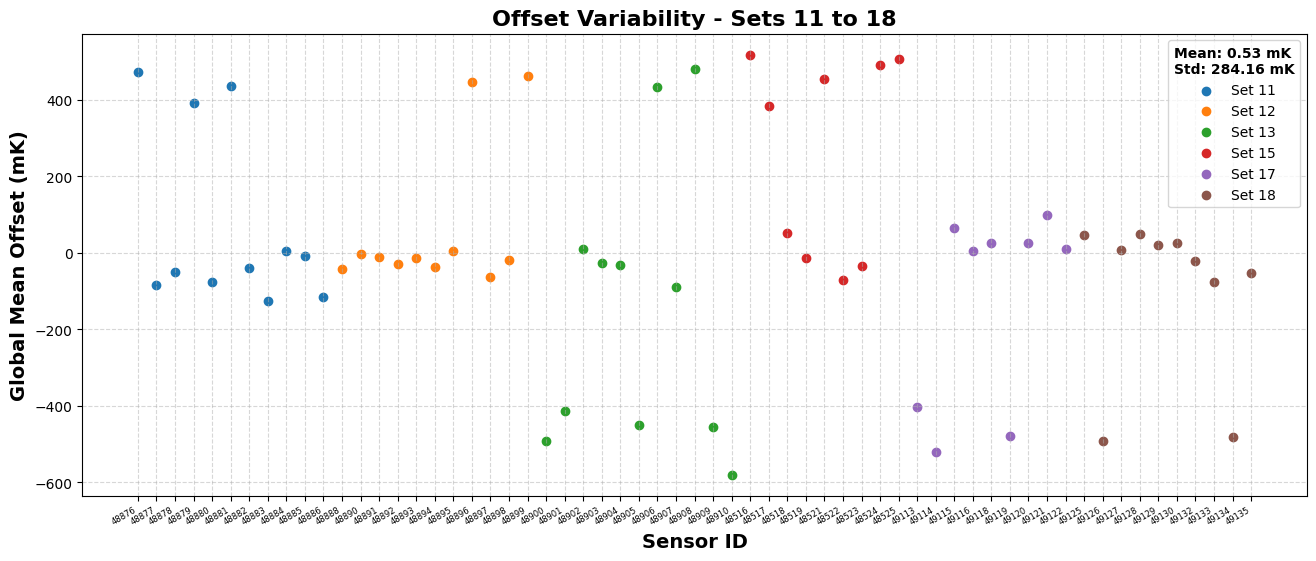

Set 21: len sensor_names=9, len global_means=9
  First sensor_name: '49192' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(19.496700134123955) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 22: len sensor_names=9, len global_means=9
  First sensor_name: '49203' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-16.361026120233838) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 25: len sensor_names=9, len global_means=9
  First sensor_name: '49250' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(5.353061249734044) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 26: len sensor_names=8, len global_means=8
  First sensor_name: '55069' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-75.36147611951102) (type: <class 'numpy.float64'>)
  All global_mean types: {'fl

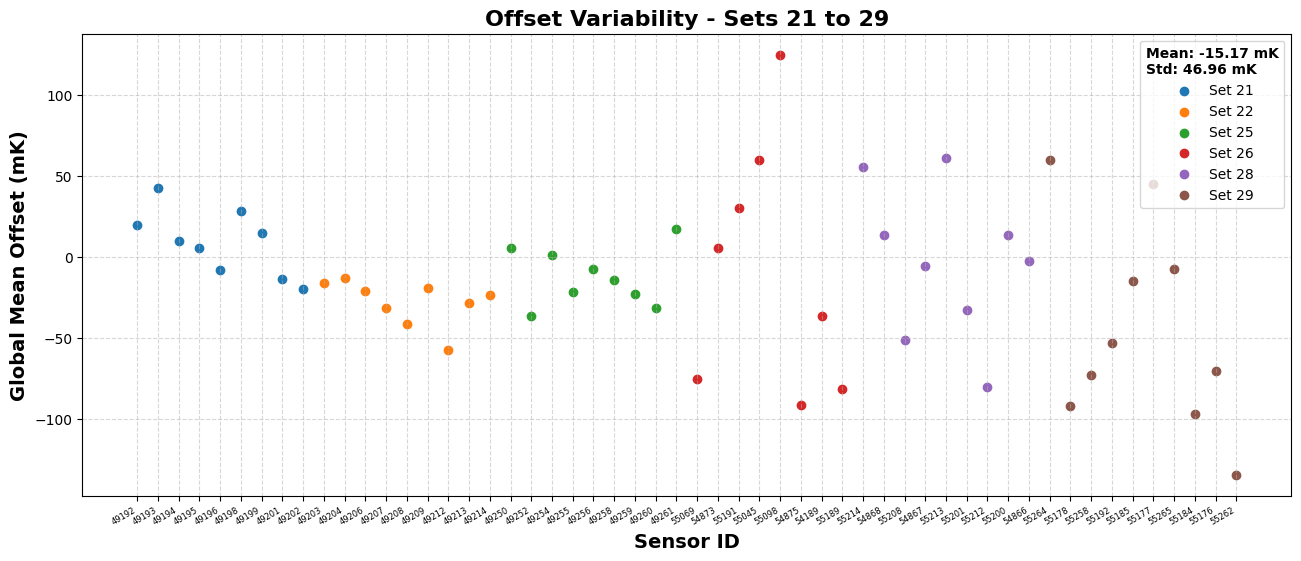

Set 31: len sensor_names=10, len global_means=10
  First sensor_name: '55179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(229.39273056790006) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 32: len sensor_names=10, len global_means=10
  First sensor_name: '55247' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-43.748213067542714) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 37: len sensor_names=9, len global_means=9
  First sensor_name: '55063' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-10.88730236355016) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 38: len sensor_names=10, len global_means=10
  First sensor_name: '55218' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(35.93507613274094) (type: <class 'numpy.float64'>)
  All global_mean types

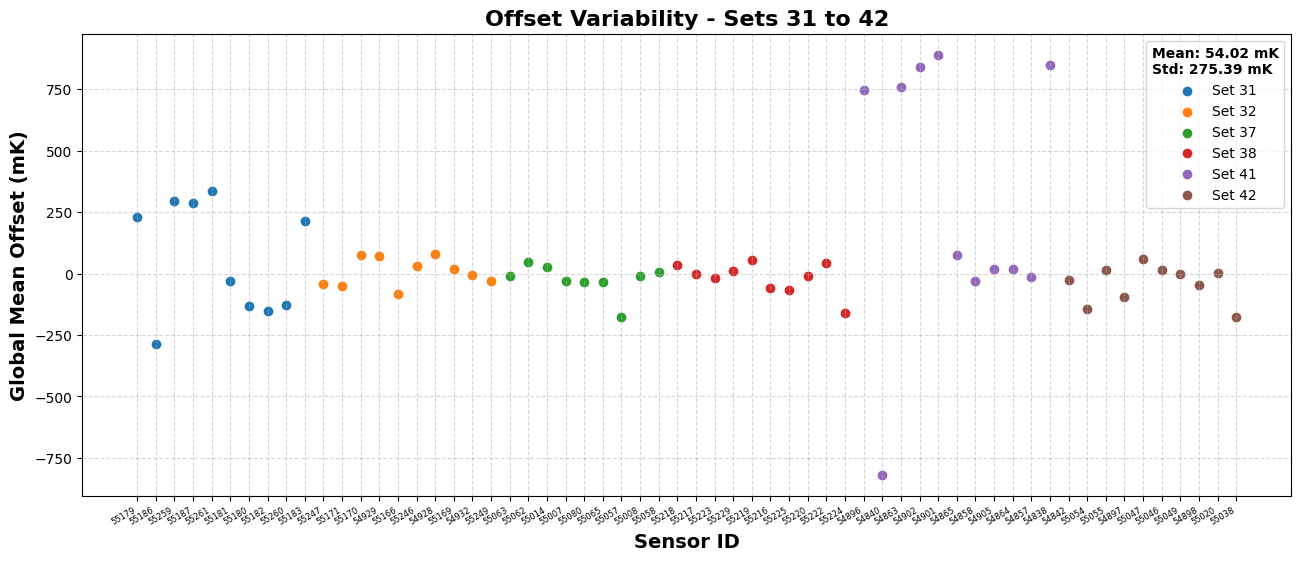

Set 44: len sensor_names=11, len global_means=11
  First sensor_name: '54856' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(3.5940880454186144) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 47: len sensor_names=10, len global_means=10
  First sensor_name: '55190' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(3.777899346017095) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 49: len sensor_names=11, len global_means=11
  First sensor_name: '48203' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(83.35971970010517) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 51: len sensor_names=11, len global_means=11
  First sensor_name: '49106' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(84.16268108018272) (type: <class 'numpy.float64'>)
  All global_mean types:

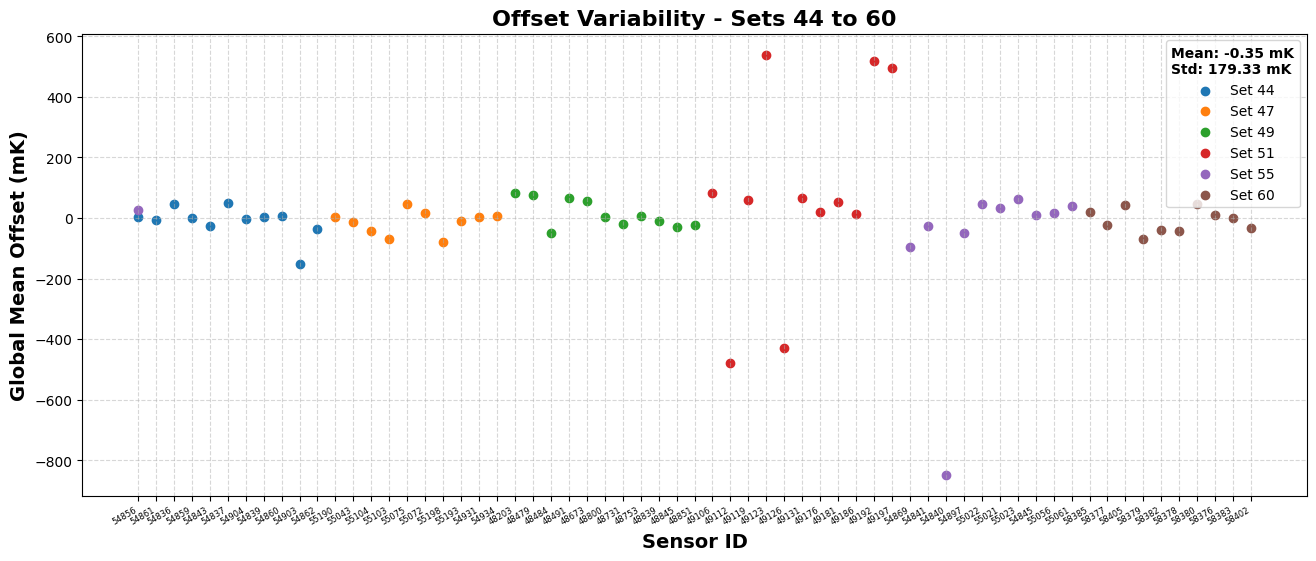

In [4]:
# 9. Plot the global mean of offsets per sensor
set_instance.plot_global_means(selected_sets=selected_sets)
# set_instance.plot_global_means()

Processing 30 sets.


/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:1444: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=legend_title, title_fontproperties={'weight': 'bold'}, loc='upper left')


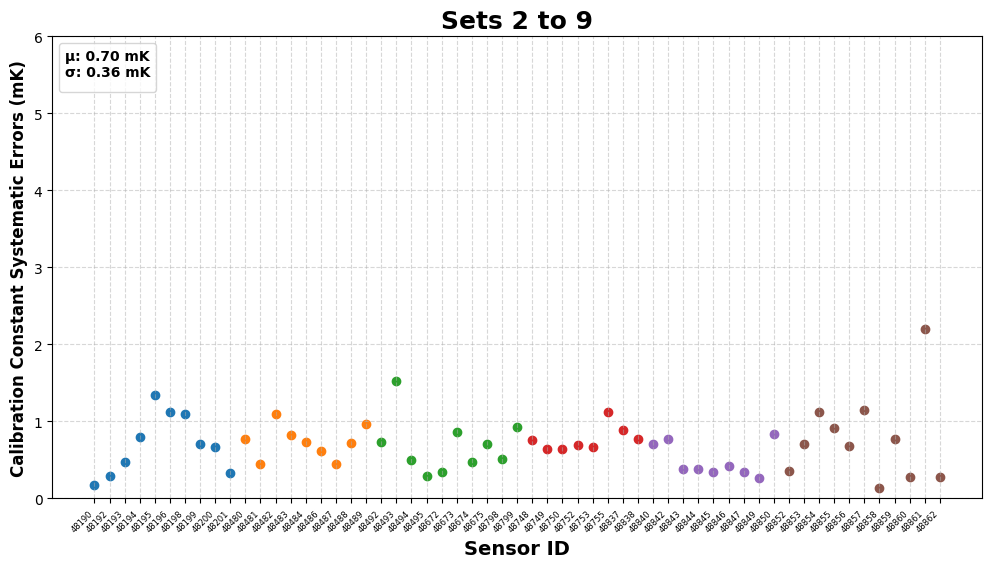

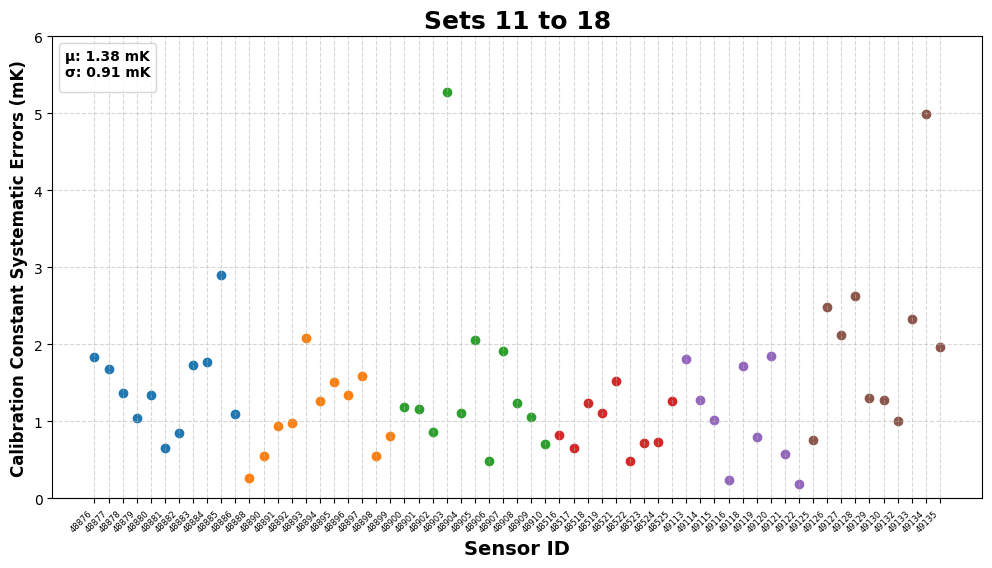

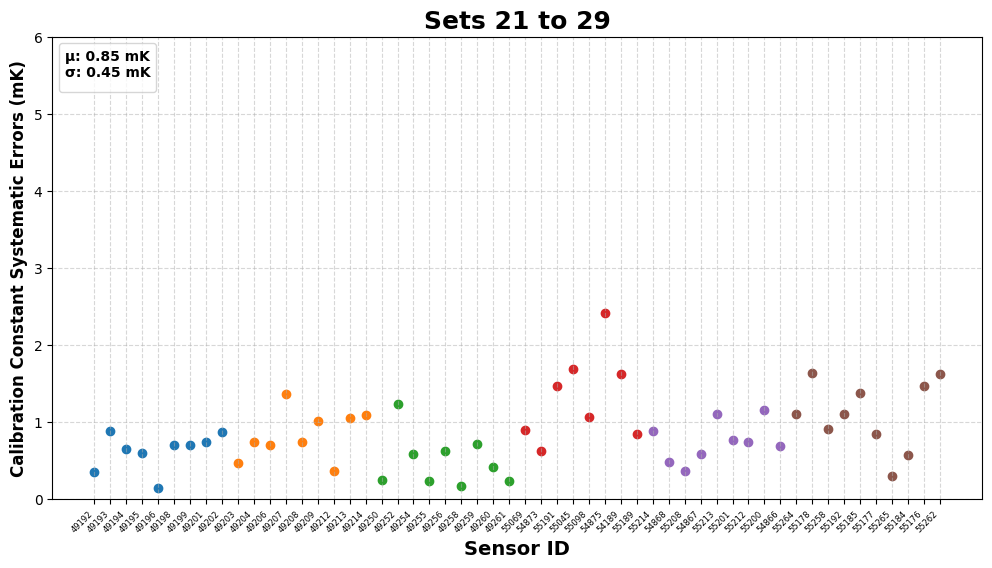

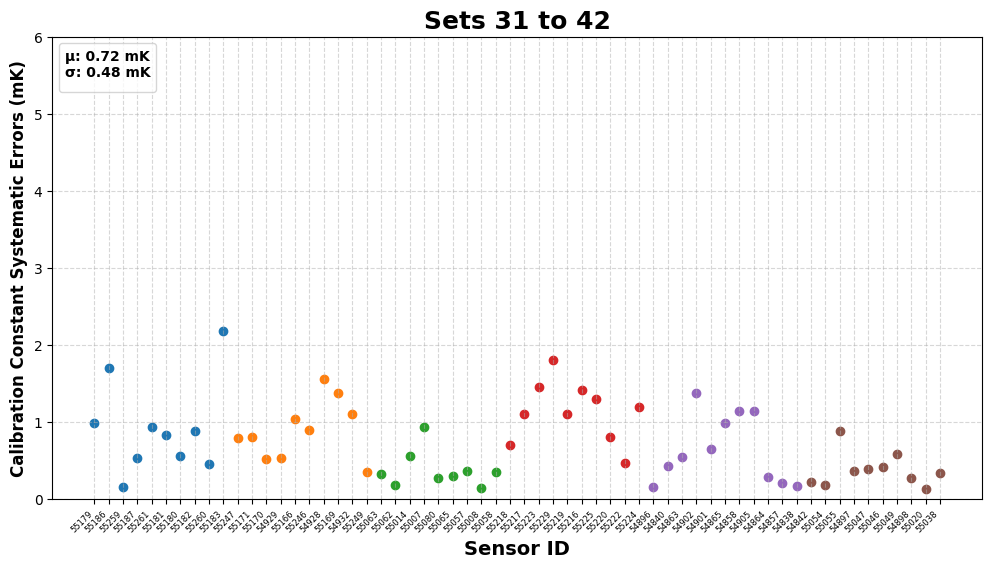

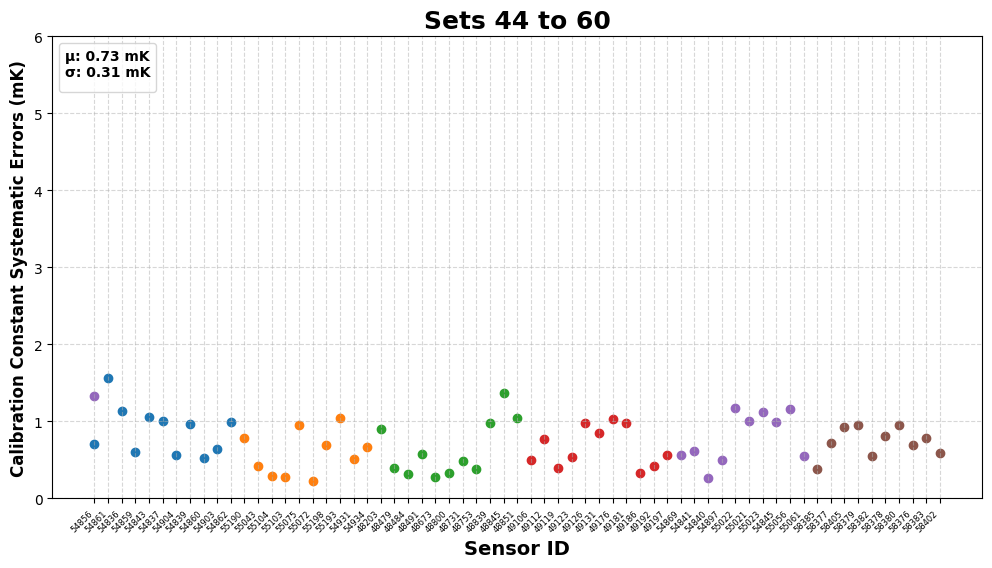

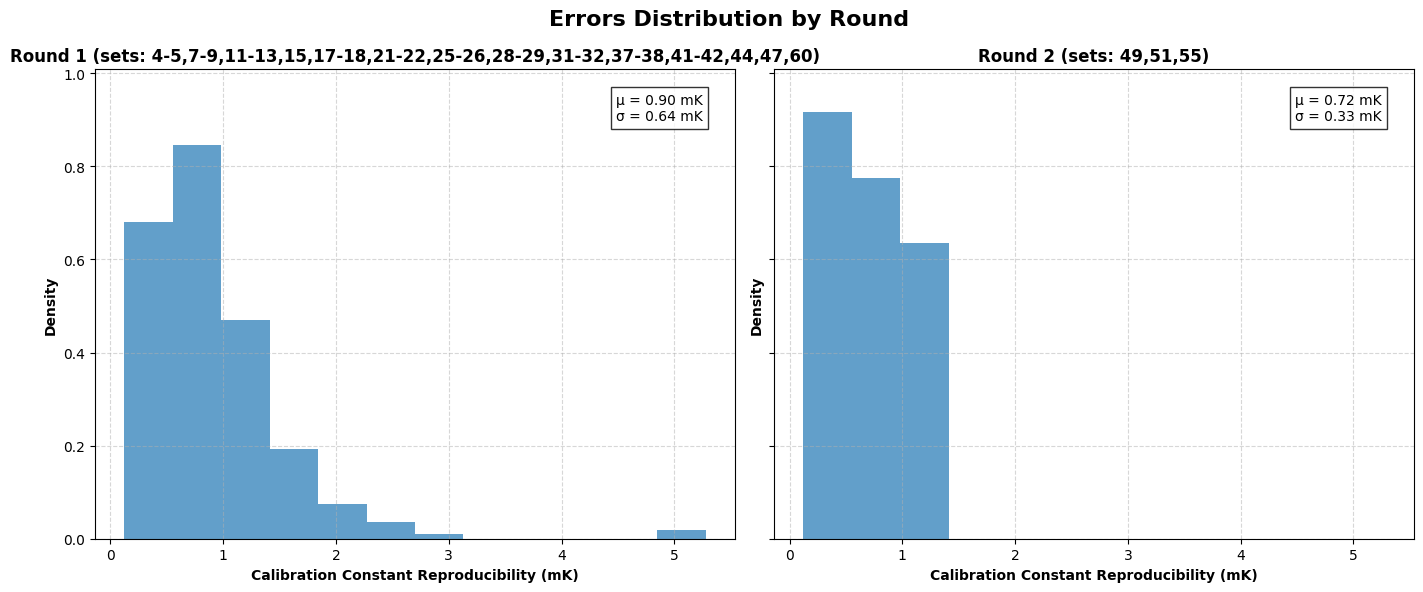

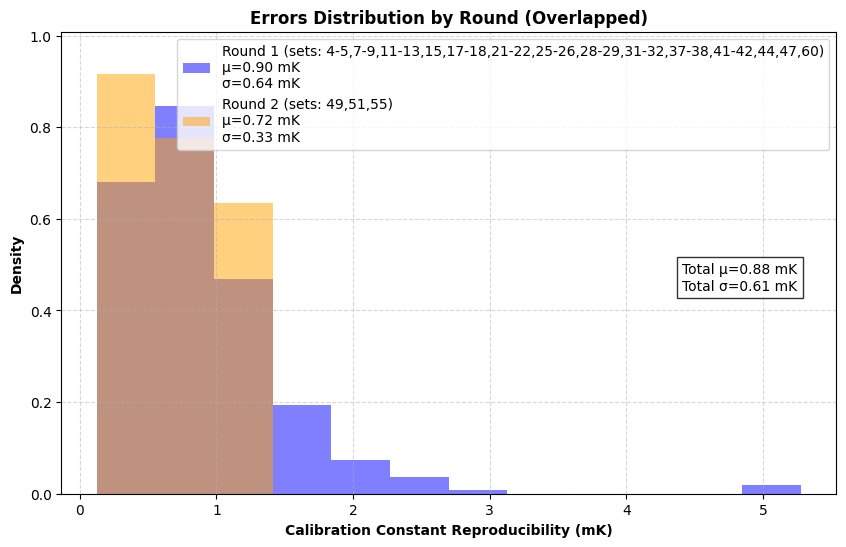

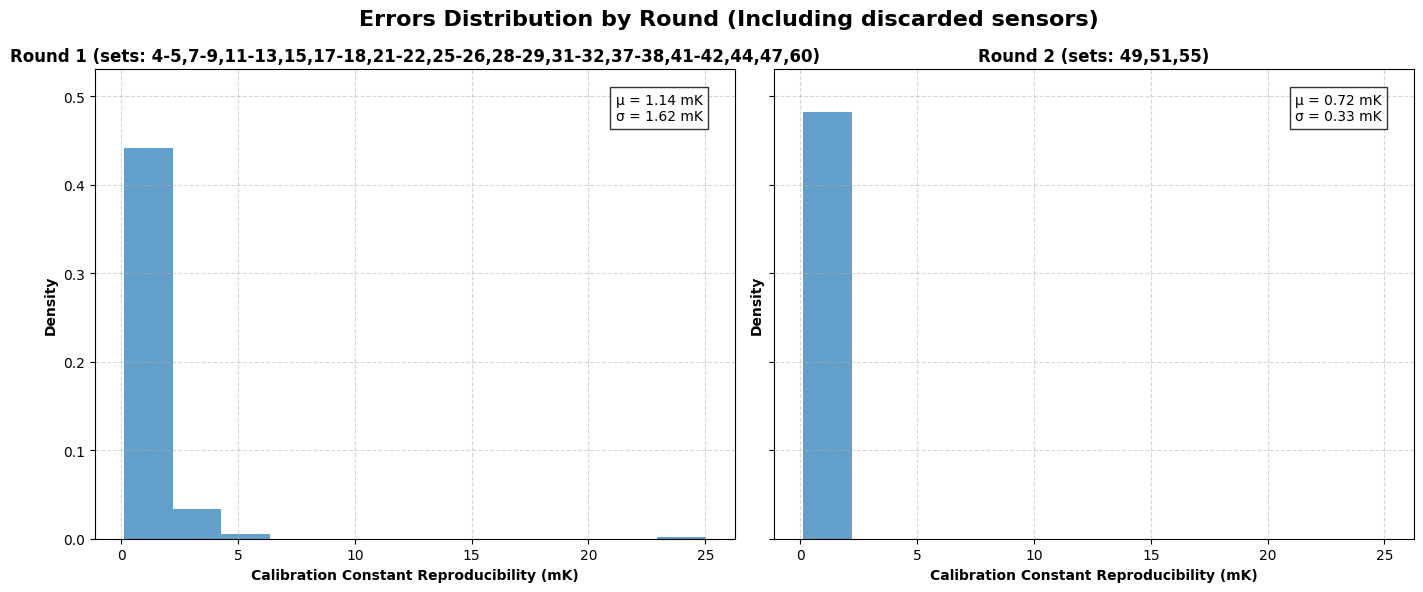

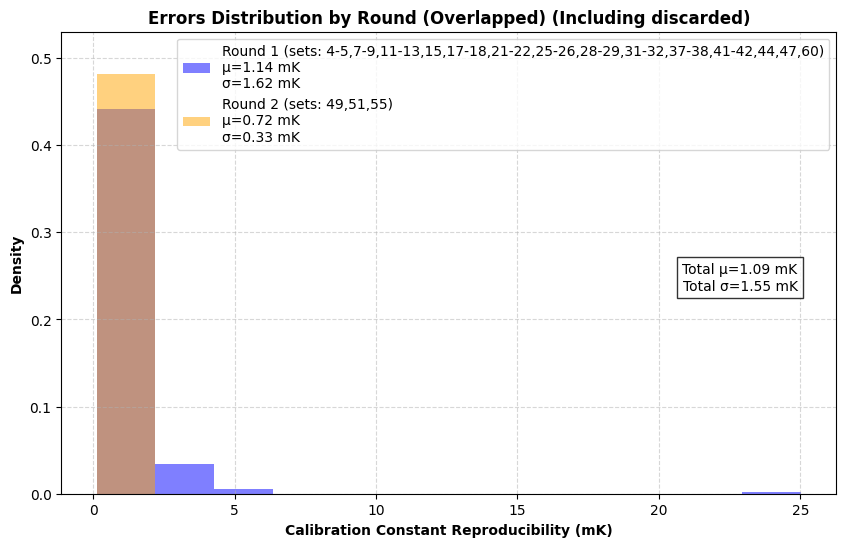

In [5]:
# 10. Plot the global sigma of offsets per sensor
set_instance.plot_global_sigmas(selected_sets=selected_sets)
# set_instance.plot_global_sigmas()